In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ewatercycle.models import Wflow
from ewatercycle.parameter_sets import available_parameter_sets

In [4]:
parameter_sets = available_parameter_sets(target_model='wflow')

print(parameter_sets.keys())

dict_keys(['wflow_rhine_sbm_nc', 'wflow_Rhine_ERA5-calibrated', 'wflow_Great-Kei_ERA5-calibrated', 'wflow_Doring_ERA5-calibrated', 'wflow_Merrimack_ERA5-calibrated', 'wflow_Meuse_ERA5-calibrated', 'wflow_rhine_ERA_Interim-calibrated', 'wflow_Savannah_ERA-Interim-calibrated', 'wflow_Great-Kei_ERA_Interim-calibrated', 'wflow_Merrimack_ERA_Interim-calibrated', 'wflow_Meuse_ERA_Interim-calibrated', 'wflow_merrimack_techpaper'])


In [6]:
parameter_set = parameter_sets["wflow_rhine_sbm_nc"]

print(parameter_set)
print(parameter_set.directory)
print(parameter_set.config)

Parameter set
-------------
name=wflow_rhine_sbm_nc
directory=/data/shared/parameter-sets/wflow_rhine_sbm_nc
config=/data/shared/parameter-sets/wflow_rhine_sbm_nc/wflow_sbm_NC.ini
doi=N/A
target_model=wflow
supported_model_versions={'2020.1.3', '2020.1.1', '2020.1.2'}
downloader=None
/data/shared/parameter-sets/wflow_rhine_sbm_nc
/data/shared/parameter-sets/wflow_rhine_sbm_nc/wflow_sbm_NC.ini


In [7]:
parameter_set.config = Path(parameter_set.directory) / "wflow_sbm_NC.ini"

print(parameter_set.config)
print(parameter_set.config.exists())

/data/shared/parameter-sets/wflow_rhine_sbm_nc/wflow_sbm_NC.ini
True


In [8]:
model = Wflow(parameter_set=parameter_set)

cfg_file, cfg_dir = model.setup()

print("Config file:", cfg_file)
print("Config directory:", cfg_dir)

Config file: /home/niels/BEP-Niels/Troepnotebooks/wflow_20260515_083350/wflow_ewatercycle.ini
Config directory: /home/niels/BEP-Niels/Troepnotebooks/wflow_20260515_083350


In [9]:
model.initialize(cfg_file)

print("Start time:", model.start_time)
print("End time:", model.end_time)
print("Current time:", model.time)
print("Output variables:", model.output_var_names)

Start time: 665366400.0
End time: 667785600.0
Current time: 665280000.0
Output variables: ('RiverRunoff',)


In [19]:
lat_lobith = 51.86
lon_lobith = 6.05

In [24]:
try:
    model.finalize()
except:
    pass

In [25]:
model = Wflow(parameter_set=parameter_set)

cfg_file, cfg_dir = model.setup()
model.initialize(cfg_file)

print("Start time:", model.start_time)
print("End time:", model.end_time)
print("Current time:", model.time)
print("Output variables:", model.output_var_names)

Start time: 665366400.0
End time: 667785600.0
Current time: 665280000.0
Output variables: ('RiverRunoff',)


In [26]:
lat_lobith_model = 51.86
lon_lobith_model = 6.05

print("Gebruikte modelcoördinaat voor Lobith:")
print("Latitude:", lat_lobith_model)
print("Longitude:", lon_lobith_model)

Gebruikte modelcoördinaat voor Lobith:
Latitude: 51.86
Longitude: 6.05


In [27]:
model.update()

q_lobith = model.get_value_at_coords(
    "RiverRunoff",
    lat=[lat_lobith_model],
    lon=[lon_lobith_model]
)[0]

print("Datum/tijd:", model.time_as_datetime)
print("Afvoer bij Lobith-modelcel:", q_lobith, "m³/s")

Datum/tijd: 1991-02-01 00:00:00
Afvoer bij Lobith-modelcel: 1.4530468e-09 m³/s


In [28]:
test_points = [
    ("Lobith origineel", 51.86, 6.12),
    ("iets west",       51.86, 6.05),
    ("iets oost",       51.86, 6.20),
    ("iets noord",      51.90, 6.12),
    ("iets zuid",       51.80, 6.12),
    ("Emmerich",        51.83, 6.24),
]

for name, lat, lon in test_points:
    q = model.get_value_at_coords(
        "RiverRunoff",
        lat=[lat],
        lon=[lon]
    )[0]
    
    print(name, lat, lon, q)

Lobith origineel 51.86 6.12 0.0
iets west 51.86 6.05 1.4530468e-09
iets oost 51.86 6.2 0.0
iets noord 51.9 6.12 0.0
iets zuid 51.8 6.12 0.0
Emmerich 51.83 6.24 2.0268253e-08


In [29]:
lat_values = np.arange(51.70, 52.00, 0.01)
lon_values = np.arange(5.90, 6.40, 0.01)

results = []

for lat in lat_values:
    for lon in lon_values:
        q = model.get_value_at_coords(
            "RiverRunoff",
            lat=[lat],
            lon=[lon]
        )[0]
        
        results.append([lat, lon, float(q)])

near_lobith = pd.DataFrame(
    results,
    columns=["lat", "lon", "Q_model_m3s"]
)

near_lobith.sort_values("Q_model_m3s", ascending=False).head(20)

,lat,lon,Q_model_m3s
99,51.71,6.39,1.542651e-06
249,51.74,6.39,1.542651e-06
149,51.72,6.39,1.542651e-06
199,51.73,6.39,1.542651e-06
655,51.83,5.95,5.075920e-07
756,51.85,5.96,5.075920e-07
607,51.82,5.97,5.075920e-07
606,51.82,5.96,5.075920e-07
605,51.82,5.95,5.075920e-07
705,51.84,5.95,5.075920e-07


In [30]:
try:
    model.finalize()
except:
    pass

model = Wflow(parameter_set=parameter_set)

cfg_file, cfg_dir = model.setup()
model.initialize(cfg_file)

print("Config file:", cfg_file)
print("Config directory:", cfg_dir)
print("Start time:", model.start_time)
print("End time:", model.end_time)
print("Current time before update:", model.time)

model.update()

print("Current time after update:", model.time_as_datetime)

test_points = [
    ("Lobith origineel", 51.86, 6.12),
    ("iets west",       51.86, 6.05),
    ("iets oost",       51.86, 6.20),
    ("iets noord",      51.90, 6.12),
    ("iets zuid",       51.80, 6.12),
    ("Emmerich",        51.83, 6.24),
]

for name, lat, lon in test_points:
    q = model.get_value_at_coords(
        "RiverRunoff",
        lat=[lat],
        lon=[lon]
    )[0]
    
    print(name, lat, lon, q)

runoff_grid = model.get_value("RiverRunoff")

print("Grid minimum:", np.nanmin(runoff_grid))
print("Grid maximum:", np.nanmax(runoff_grid))
print("Grid mean:", np.nanmean(runoff_grid))
print("Aantal niet-nul cellen:", np.count_nonzero(runoff_grid))

Config file: /home/niels/BEP-Niels/Troepnotebooks/wflow_20260515_084758/wflow_ewatercycle.ini
Config directory: /home/niels/BEP-Niels/Troepnotebooks/wflow_20260515_084758
Start time: 665366400.0
End time: 667785600.0
Current time before update: 665280000.0
Current time after update: 1991-02-01 00:00:00
Lobith origineel 51.86 6.12 0.0
iets west 51.86 6.05 1.4530468e-09
iets oost 51.86 6.2 0.0
iets noord 51.9 6.12 0.0
iets zuid 51.8 6.12 0.0
Emmerich 51.83 6.24 2.0268253e-08
Grid minimum: 0.0
Grid maximum: 0.051194504
Grid mean: 5.4860204e-05
Aantal niet-nul cellen: 1393


In [31]:
try:
    model.finalize()
except:
    pass

model = Wflow(parameter_set=parameter_set)

cfg_file, cfg_dir = model.setup()
model.initialize(cfg_file)

test_points = [
    ("Lobith origineel", 51.86, 6.12),
    ("iets west",       51.86, 6.05),
    ("iets oost",       51.86, 6.20),
    ("iets noord",      51.90, 6.12),
    ("iets zuid",       51.80, 6.12),
    ("Emmerich",        51.83, 6.24),
]

for i in range(35):
    if model.time >= model.end_time:
        break
    
    model.update()
    
    runoff_grid = model.get_value("RiverRunoff")
    
    print("\nDag:", i + 1)
    print("Tijd:", model.time_as_datetime)
    print("Grid max:", np.nanmax(runoff_grid))
    
    for name, lat, lon in test_points:
        q = model.get_value_at_coords(
            "RiverRunoff",
            lat=[lat],
            lon=[lon]
        )[0]
        
        print(name, q)


Dag: 1
Tijd: 1991-02-01 00:00:00
Grid max: 0.051194504
Lobith origineel 0.0
iets west 1.4530468e-09
iets oost 0.0
iets noord 0.0
iets zuid 0.0
Emmerich 2.0268253e-08

Dag: 2
Tijd: 1991-02-02 00:00:00
Grid max: 0.10605591
Lobith origineel 0.0
iets west 0.0030140437
iets oost 0.0
iets noord 0.0
iets zuid 0.0
Emmerich 0.0002763821

Dag: 3
Tijd: 1991-02-03 00:00:00
Grid max: 0.21594489
Lobith origineel 0.0
iets west 0.0031291898
iets oost 0.0
iets noord 0.0
iets zuid 0.0
Emmerich 0.00027773692

Dag: 4
Tijd: 1991-02-04 00:00:00
Grid max: 0.29610422
Lobith origineel 0.0
iets west 0.014018101
iets oost 0.0
iets noord 0.0
iets zuid 0.0
Emmerich 0.0009906616

Dag: 5
Tijd: 1991-02-05 00:00:00
Grid max: 0.29171675
Lobith origineel 0.0
iets west 0.011991496
iets oost 0.0
iets noord 0.0
iets zuid 0.0
Emmerich 0.00064370444

Dag: 6
Tijd: 1991-02-06 00:00:00
Grid max: 0.28524807
Lobith origineel 0.0
iets west 0.009143784
iets oost 0.0
iets noord 0.0
iets zuid 0.0
Emmerich 0.0003428993

Dag: 7
Tijd: 

In [32]:
lat_values = np.arange(51.60, 52.10, 0.01)
lon_values = np.arange(5.70, 6.70, 0.01)

results = []

for lat in lat_values:
    for lon in lon_values:
        q = model.get_value_at_coords(
            "RiverRunoff",
            lat=[lat],
            lon=[lon]
        )[0]
        
        results.append([lat, lon, float(q)])

near_lobith = pd.DataFrame(
    results,
    columns=["lat", "lon", "Q_model_m3s"]
)

near_lobith.sort_values("Q_model_m3s", ascending=False).head(20)

,lat,lon,Q_model_m3s
3002,51.90,5.72,2191.815430
3100,51.91,5.70,2191.815430
2900,51.89,5.70,2191.815430
2901,51.89,5.71,2191.815430
2902,51.89,5.72,2191.815430
3202,51.92,5.72,2191.815430
3201,51.92,5.71,2191.815430
3200,51.92,5.70,2191.815430
3001,51.90,5.71,2191.815430
3102,51.91,5.72,2191.815430


In [33]:
best_point = near_lobith.sort_values("Q_model_m3s", ascending=False).iloc[0]

lat_lobith_model = best_point["lat"]
lon_lobith_model = best_point["lon"]

print("Beste modelcel rond Lobith:")
print("Latitude:", lat_lobith_model)
print("Longitude:", lon_lobith_model)
print("Afvoer:", best_point["Q_model_m3s"], "m³/s")

Beste modelcel rond Lobith:
Latitude: 51.89999999999994
Longitude: 5.72
Afvoer: 2191.8154296875 m³/s


In [34]:
try:
    model.finalize()
except:
    pass

model = Wflow(parameter_set=parameter_set)

cfg_file, cfg_dir = model.setup()
model.initialize(cfg_file)

Q_model = []
time_model = []

while model.time < model.end_time:
    model.update()
    
    q_lobith = model.get_value_at_coords(
        "RiverRunoff",
        lat=[lat_lobith_model],
        lon=[lon_lobith_model]
    )[0]
    
    Q_model.append(float(q_lobith))
    time_model.append(model.time_as_datetime)

model_output = pd.DataFrame({
    "date": pd.to_datetime(time_model),
    "Q_model_m3s": Q_model
})

model_output.head()

,date,Q_model_m3s
0,1991-02-01,4.195876e-08
1,1991-02-02,1.767313e-03
2,1991-02-03,1.837913e-03
3,1991-02-04,1.366903e-02
4,1991-02-05,1.144263e-02


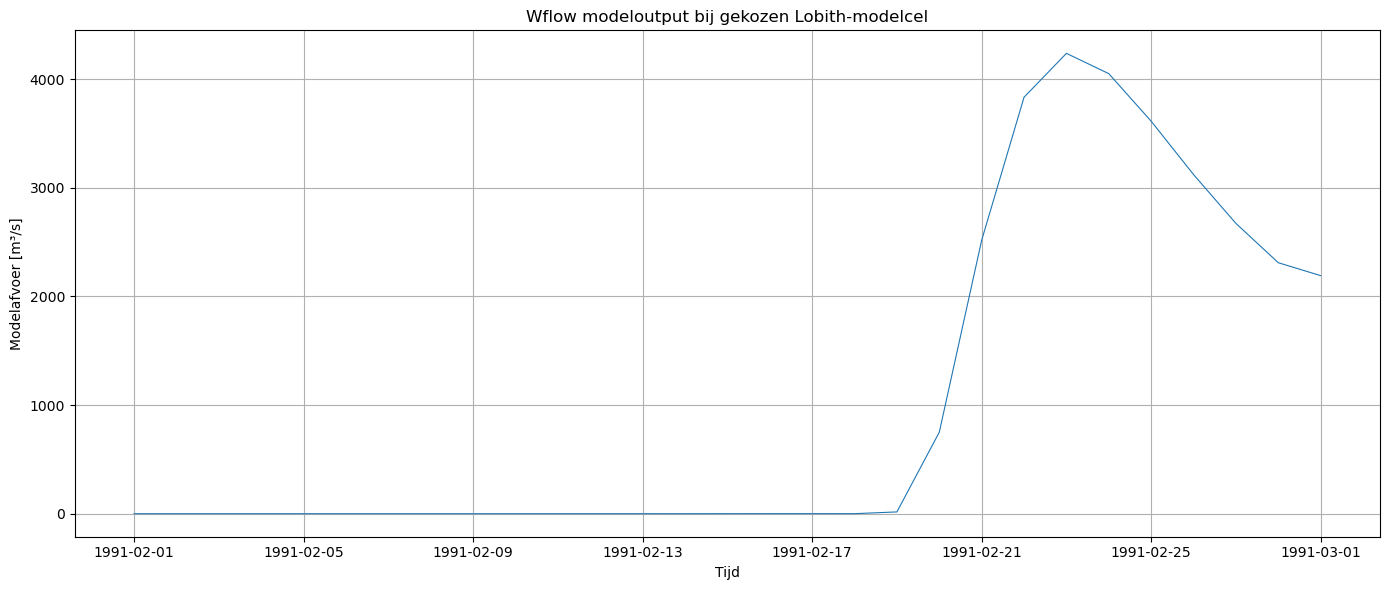

In [35]:
plt.figure(figsize=(14, 6))

plt.plot(
    model_output["date"],
    model_output["Q_model_m3s"],
    linewidth=0.8
)

plt.xlabel("Tijd")
plt.ylabel("Modelafvoer [m³/s]")
plt.title("Wflow modeloutput bij gekozen Lobith-modelcel")
plt.grid(True)

plt.tight_layout()
plt.show()

In [36]:
model_output_clean = model_output[model_output["date"] >= "1991-02-15"]

In [37]:
near_lobith.sort_values("Q_model_m3s", ascending=False).head(20)

,lat,lon,Q_model_m3s
3002,51.90,5.72,2191.815430
3100,51.91,5.70,2191.815430
2900,51.89,5.70,2191.815430
2901,51.89,5.71,2191.815430
2902,51.89,5.72,2191.815430
3202,51.92,5.72,2191.815430
3201,51.92,5.71,2191.815430
3200,51.92,5.70,2191.815430
3001,51.90,5.71,2191.815430
3102,51.91,5.72,2191.815430


In [38]:
lat_lobith_model = 51.90
lon_lobith_model = 5.72

print("Gekozen Lobith-modelcel:")
print("Latitude:", lat_lobith_model)
print("Longitude:", lon_lobith_model)

Gekozen Lobith-modelcel:
Latitude: 51.9
Longitude: 5.72


In [39]:
try:
    model.finalize()
except:
    pass

model = Wflow(parameter_set=parameter_set)

cfg_file, cfg_dir = model.setup()
model.initialize(cfg_file)

Q_model = []
time_model = []

while model.time < model.end_time:
    model.update()
    
    q_lobith = model.get_value_at_coords(
        "RiverRunoff",
        lat=[lat_lobith_model],
        lon=[lon_lobith_model]
    )[0]
    
    Q_model.append(float(q_lobith))
    time_model.append(model.time_as_datetime)

model_output = pd.DataFrame({
    "date": pd.to_datetime(time_model),
    "Q_model_m3s": Q_model
})

model_output.head()

,date,Q_model_m3s
0,1991-02-01,4.195876e-08
1,1991-02-02,1.767313e-03
2,1991-02-03,1.837913e-03
3,1991-02-04,1.366903e-02
4,1991-02-05,1.144263e-02


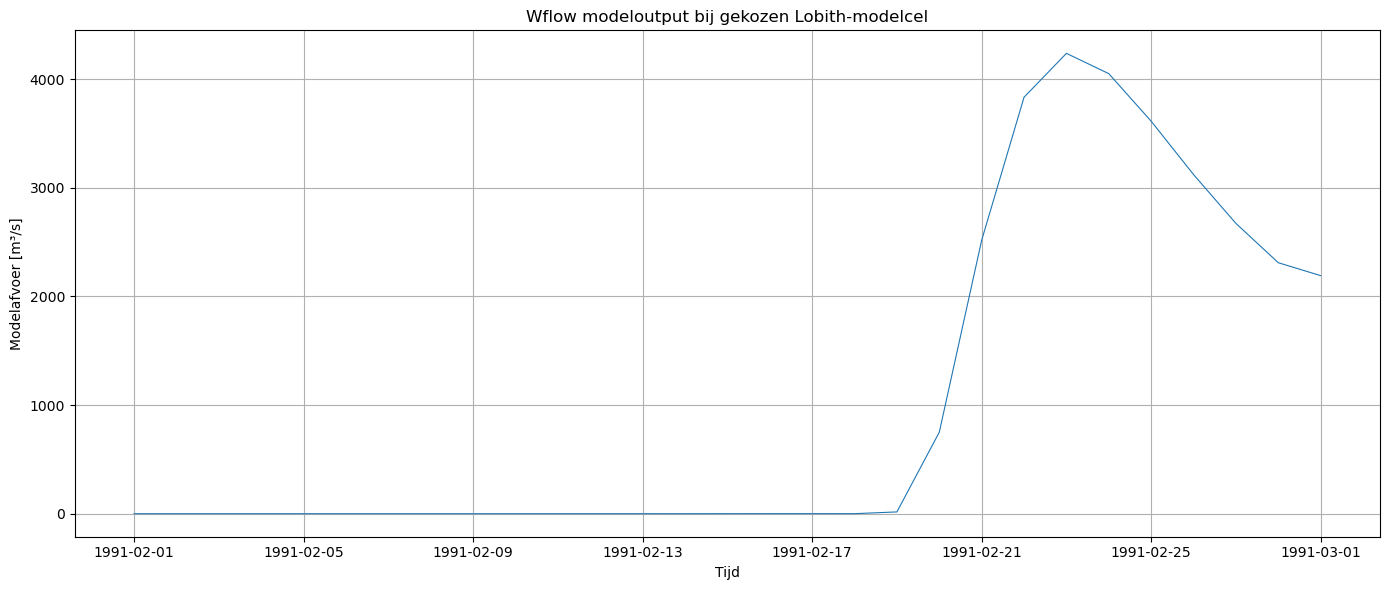

In [40]:
plt.figure(figsize=(14, 6))

plt.plot(
    model_output["date"],
    model_output["Q_model_m3s"],
    linewidth=0.8
)

plt.xlabel("Tijd")
plt.ylabel("Modelafvoer [m³/s]")
plt.title("Wflow modeloutput bij gekozen Lobith-modelcel")
plt.grid(True)

plt.tight_layout()
plt.show()

In [41]:
model_output_clean = model_output[model_output["date"] >= "1991-02-15"].copy()

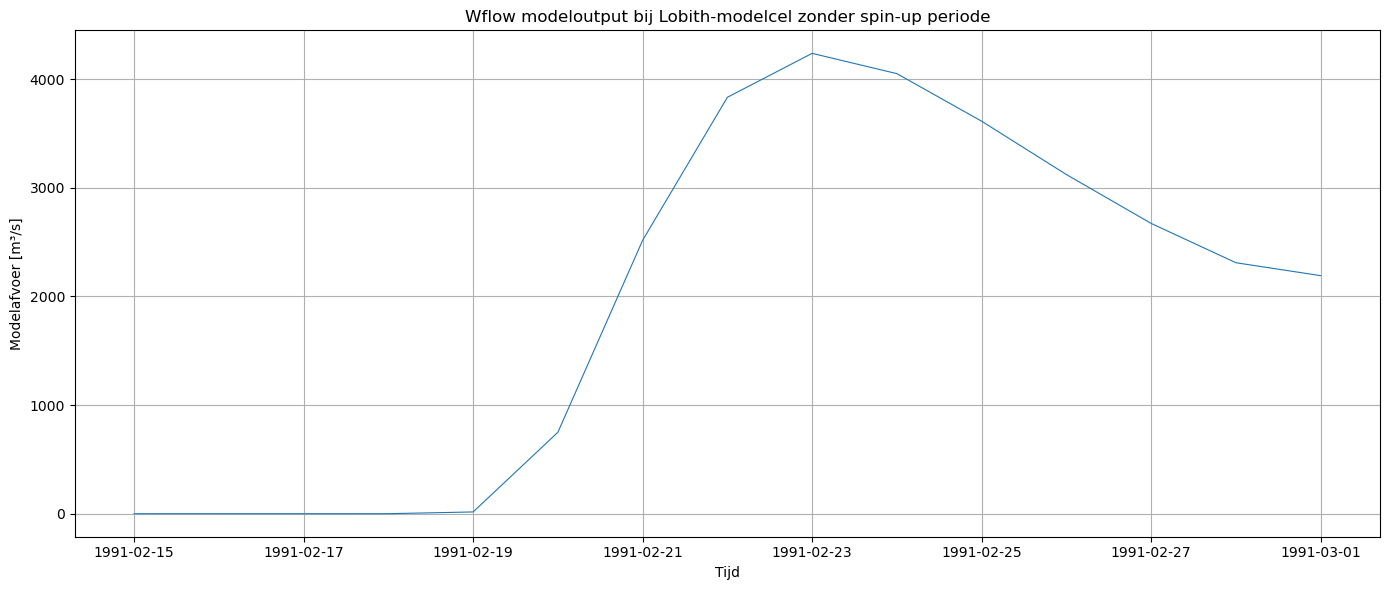

In [42]:
plt.figure(figsize=(14, 6))

plt.plot(
    model_output_clean["date"],
    model_output_clean["Q_model_m3s"],
    linewidth=0.8
)

plt.xlabel("Tijd")
plt.ylabel("Modelafvoer [m³/s]")
plt.title("Wflow modeloutput bij Lobith-modelcel zonder spin-up periode")
plt.grid(True)

plt.tight_layout()
plt.show()

In [43]:
model_daily = (
    model_output_clean
    .set_index("date")
    .resample("D")["Q_model_m3s"]
    .mean()
    .reset_index()
)

model_daily.head()

,date,Q_model_m3s
0,1991-02-15,0.247491
1,1991-02-16,0.336610
2,1991-02-17,0.363614
3,1991-02-18,0.442735
4,1991-02-19,16.409237


In [44]:
from pathlib import Path
import xarray as xr

forcing_file = Path(parameter_set.directory) / "inmaps.nc"

forcing_ds = xr.open_dataset(forcing_file)

print("Start forcing:", forcing_ds.time.min().values)
print("End forcing:", forcing_ds.time.max().values)
print("Aantal tijdstappen:", len(forcing_ds.time))

Start forcing: 1991-01-01T00:00:00.000000000
End forcing: 1991-12-31T00:00:00.000000000
Aantal tijdstappen: 365


In [52]:
from pathlib import Path

log_file = Path("/home/niels/BEP-Niels/Troepnotebooks/wflow_forcing_ERA5_1990_1994/run/diagnostic/script/log.txt")

print(log_file.exists())

True


In [53]:
with open(log_file, "r") as f:
    log_text = f.read()

print(log_text[-4000:])

995
    type: reanaly
    units: W m-2
    variable_group: rsds
    version: 1
  ? /home/niels/BEP-Niels/Troepnotebooks/wflow_forcing_ERA5_1990_1994/preproc/diagnostic/rsdt/OBS6_ERA5_reanaly_1_CFday_rsdt_1990-1995.nc
  : alias: ERA5
    dataset: ERA5
    diagnostic: diagnostic
    end_year: 1995
    filename: /home/niels/BEP-Niels/Troepnotebooks/wflow_forcing_ERA5_1990_1994/preproc/diagnostic/rsdt/OBS6_ERA5_reanaly_1_CFday_rsdt_1990-1995.nc
    frequency: day
    long_name: TOA Incident Shortwave Radiation
    mip: CFday
    modeling_realm:
    - atmos
    preprocessor: rsdt
    project: OBS6
    recipe_dataset_index: 0
    short_name: rsdt
    standard_name: toa_incoming_shortwave_flux
    start_year: 1990
    tier: 3
    timerange: 1990/1995
    type: reanaly
    units: W m-2
    variable_group: rsdt
    version: 1
  ? /home/niels/BEP-Niels/Troepnotebooks/wflow_forcing_ERA5_1990_1994/preproc/diagnostic/tas/OBS6_ERA5_reanaly_1_day_tas_1990-1995.nc
  : alias: ERA5
    dataset: ERA5
   

In [54]:
from pathlib import Path

base_dir = Path("/home/niels/BEP-Niels")

dem_files = list(base_dir.rglob("*dem*"))

for file in dem_files:
    print(file)

/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/dem.map
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/wflow_dem.map
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/wflow_dem10.map
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/wflow_dem25.map
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/wflow_dem33.map
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/wflow_dem66.map
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/wflow_dem75.map
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/wflow_dem90.map
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/wflow_demmax.map
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/wflow_demmin.map
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/wflow_riverdem.map
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_124812/

In [55]:
shape_file = Path("/home/niels/BEP-Niels/Rhine/Rhine.shp")
dem_file = Path("/home/niels/BEP-Niels/wflow_20260513_101120/staticmaps/wflow_dem.map")

print("Shape bestaat:", shape_file.exists())
print("DEM bestaat:", dem_file.exists())

Shape bestaat: True
DEM bestaat: True


In [59]:
from pathlib import Path

log_file = Path(
    "/home/niels/BEP-Niels/Troepnotebooks/"
    "wflow_forcing_ERA5_1990_1994_with_dem_v2/"
    "run/diagnostic/script/log.txt"
)

print(log_file.exists())

with open(log_file, "r") as f:
    log_text = f.read()

print(log_text[-5000:])

True
dt_1990-1995.nc
  : alias: ERA5
    dataset: ERA5
    diagnostic: diagnostic
    end_year: 1995
    filename: /home/niels/BEP-Niels/Troepnotebooks/wflow_forcing_ERA5_1990_1994_with_dem_v2/preproc/diagnostic/rsdt/OBS6_ERA5_reanaly_1_CFday_rsdt_1990-1995.nc
    frequency: day
    long_name: TOA Incident Shortwave Radiation
    mip: CFday
    modeling_realm:
    - atmos
    preprocessor: rsdt
    project: OBS6
    recipe_dataset_index: 0
    short_name: rsdt
    standard_name: toa_incoming_shortwave_flux
    start_year: 1990
    tier: 3
    timerange: 1990/1995
    type: reanaly
    units: W m-2
    variable_group: rsdt
    version: 1
  ? /home/niels/BEP-Niels/Troepnotebooks/wflow_forcing_ERA5_1990_1994_with_dem_v2/preproc/diagnostic/tas/OBS6_ERA5_reanaly_1_day_tas_1990-1995.nc
  : alias: ERA5
    dataset: ERA5
    diagnostic: diagnostic
    end_year: 1995
    filename: /home/niels/BEP-Niels/Troepnotebooks/wflow_forcing_ERA5_1990_1994_with_dem_v2/preproc/diagnostic/tas/OBS6_ERA5_rean

In [60]:
from pathlib import Path

zoek_mappen = [
    Path("/home/niels/BEP-Niels"),
    Path("/data/shared/parameter-sets"),
]

for mapje in zoek_mappen:
    print("\nZoeken in:", mapje)
    
    dem_files = list(mapje.rglob("*dem*.map"))
    
    for file in dem_files:
        print(file)


Zoeken in: /home/niels/BEP-Niels
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/dem.map
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/wflow_dem.map
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/wflow_dem10.map
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/wflow_dem25.map
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/wflow_dem33.map
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/wflow_dem66.map
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/wflow_dem75.map
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/wflow_dem90.map
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/wflow_demmax.map
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/wflow_demmin.map
/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_122854/staticmaps/wflow_riverdem.map
/home/niels/BEP-Niels/Tro

In [61]:
from pathlib import Path

shape_file = Path("/home/niels/BEP-Niels/Rhine/Rhine.shp")

dem_file = Path(
    "/home/niels/BEP-Niels/Troepnotebooks/"
    "wflow_20260515_085409/staticmaps/wflow_dem.map"
)

print("Shape bestaat:", shape_file.exists())
print("DEM bestaat:", dem_file.exists())
print("DEM grootte MB:", dem_file.stat().st_size / 1_000_000)

Shape bestaat: True
DEM bestaat: True
DEM grootte MB: 0.126668


In [62]:
from ewatercycle.forcing import sources

WflowForcing = sources["WflowForcing"]

forcing = WflowForcing.generate(
    dataset="ERA5",
    start_time="1990-01-01T00:00:00Z",
    end_time="1995-01-01T00:00:00Z",
    shape=str(shape_file),
    dem_file=str(dem_file),
    directory="wflow_forcing_ERA5_1990_1994_with_correct_dem",
)

print(forcing)
print(forcing.directory)

start_time='1990-01-01T00:00:00Z' end_time='1995-01-01T00:00:00Z' directory=PosixPath('/home/niels/BEP-Niels/Troepnotebooks/wflow_forcing_ERA5_1990_1994_with_correct_dem/work/diagnostic/script') shape=PosixPath('/home/niels/BEP-Niels/Rhine/Rhine.shp') filenames={} netcdfinput='wflow_ERA5_Rhine_1990_1995.nc' Precipitation='/pr' EvapoTranspiration='/pet' Temperature='/tas' Inflow=None
/home/niels/BEP-Niels/Troepnotebooks/wflow_forcing_ERA5_1990_1994_with_correct_dem/work/diagnostic/script


In [64]:
from pathlib import Path
import xarray as xr

forcing_file = Path(
    "/home/niels/BEP-Niels/Troepnotebooks/"
    "wflow_forcing_ERA5_1990_1994_with_correct_dem/"
    "work/diagnostic/script/"
    "wflow_ERA5_Rhine_1990_1995.nc"
)

print("Forcingbestand bestaat:", forcing_file.exists())
print(forcing_file)

Forcingbestand bestaat: True
/home/niels/BEP-Niels/Troepnotebooks/wflow_forcing_ERA5_1990_1994_with_correct_dem/work/diagnostic/script/wflow_ERA5_Rhine_1990_1995.nc


In [65]:
forcing_ds = xr.open_dataset(forcing_file)

print(forcing_ds)

<xarray.Dataset> Size: 831MB
Dimensions:    (time: 2191, lat: 169, lon: 187, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 18kB 1990-01-01T12:00:00 ... 1995-12-31T...
  * lat        (lat) float64 1kB 52.05 52.02 51.98 51.94 ... 45.97 45.93 45.89
  * lon        (lon) float64 1kB 5.227 5.264 5.3 5.337 ... 11.97 12.01 12.05
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    pr         (time, lat, lon) float32 277MB ...
    time_bnds  (time, bnds) datetime64[ns] 35kB ...
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    tas        (time, lat, lon) float32 277MB ...
    pet        (time, lat, lon) float32 277MB ...
Attributes:
    Conventions:  CF-1.7
    software:     Created with ESMValTool v2.11.1
    caption:      Forcings for the wflow hydrological model.


In [66]:
print("Start forcing:", forcing_ds.time.min().values)
print("End forcing:", forcing_ds.time.max().values)
print("Aantal tijdstappen:", len(forcing_ds.time))

Start forcing: 1990-01-01T12:00:00.000000000
End forcing: 1995-12-31T12:00:00.000000000
Aantal tijdstappen: 2191


In [67]:
print(forcing_ds.data_vars)

Data variables:
    pr         (time, lat, lon) float32 277MB ...
    time_bnds  (time, bnds) datetime64[ns] 35kB ...
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    tas        (time, lat, lon) float32 277MB ...
    pet        (time, lat, lon) float32 277MB ...


In [68]:
for var in forcing_ds.data_vars:
    print("\nVariabele:", var)
    print("min:", float(forcing_ds[var].min()))
    print("max:", float(forcing_ds[var].max()))
    print("mean:", float(forcing_ds[var].mean()))


Variabele: pr
min: -1.6653344014124632e-13
max: 184.58956909179688
mean: 3.035980701446533

Variabele: time_bnds
min: 6.31152e+17
max: 8.204544e+17
mean: 7.258032e+17

Variabele: lat_bnds
min: 45.87593333581199
max: 52.07260000000001
mean: 48.97426666790601

Variabele: lon_bnds
min: 5.208829999999999
max: 12.065496663924
mean: 8.637163331962

Variabele: tas
min: -35.36530303955078
max: 29.81597328186035
mean: 8.20678424835205

Variabele: pet
min: 0.20952633023262024
max: 5.502441883087158
mean: 1.836094617843628


In [69]:
try:
    model.finalize()
except:
    pass

model = Wflow(
    parameter_set=parameter_set,
    forcing=forcing
)

cfg_file, cfg_dir = model.setup()
model.initialize(cfg_file)

print("Start time:", model.start_time)
print("End time:", model.end_time)
print("Current time:", model.time)
print("Output variables:", model.output_var_names)

Start time: 631152000.0
End time: 788918400.0
Current time: 631065600.0
Output variables: ('RiverRunoff',)


In [70]:
Q_model = []
time_model = []

while model.time < model.end_time:
    model.update()
    
    q_lobith = model.get_value_at_coords(
        "RiverRunoff",
        lat=[lat_lobith_model],
        lon=[lon_lobith_model]
    )[0]
    
    Q_model.append(float(q_lobith))
    time_model.append(model.time_as_datetime)

model_output = pd.DataFrame({
    "date": pd.to_datetime(time_model),
    "Q_model_m3s": Q_model
})

print("Aantal modelstappen:", len(model_output))
print("Eerste datum:", model_output["date"].min())
print("Laatste datum:", model_output["date"].max())

model_output.head()

Aantal modelstappen: 1827
Eerste datum: 1990-01-01 00:00:00
Laatste datum: 1995-01-01 00:00:00


,date,Q_model_m3s
0,1990-01-01,0.000031
1,1990-01-02,0.000003
2,1990-01-03,0.000001
3,1990-01-04,0.000038
4,1990-01-05,0.000015


In [71]:
model_output_validation = model_output[
    (model_output["date"] >= "1991-01-01") &
    (model_output["date"] <= "1994-12-31")
].copy()

print("Aantal validatiedagen:", len(model_output_validation))
print("Eerste validatiedatum:", model_output_validation["date"].min())
print("Laatste validatiedatum:", model_output_validation["date"].max())

Aantal validatiedagen: 1461
Eerste validatiedatum: 1991-01-01 00:00:00
Laatste validatiedatum: 1994-12-31 00:00:00


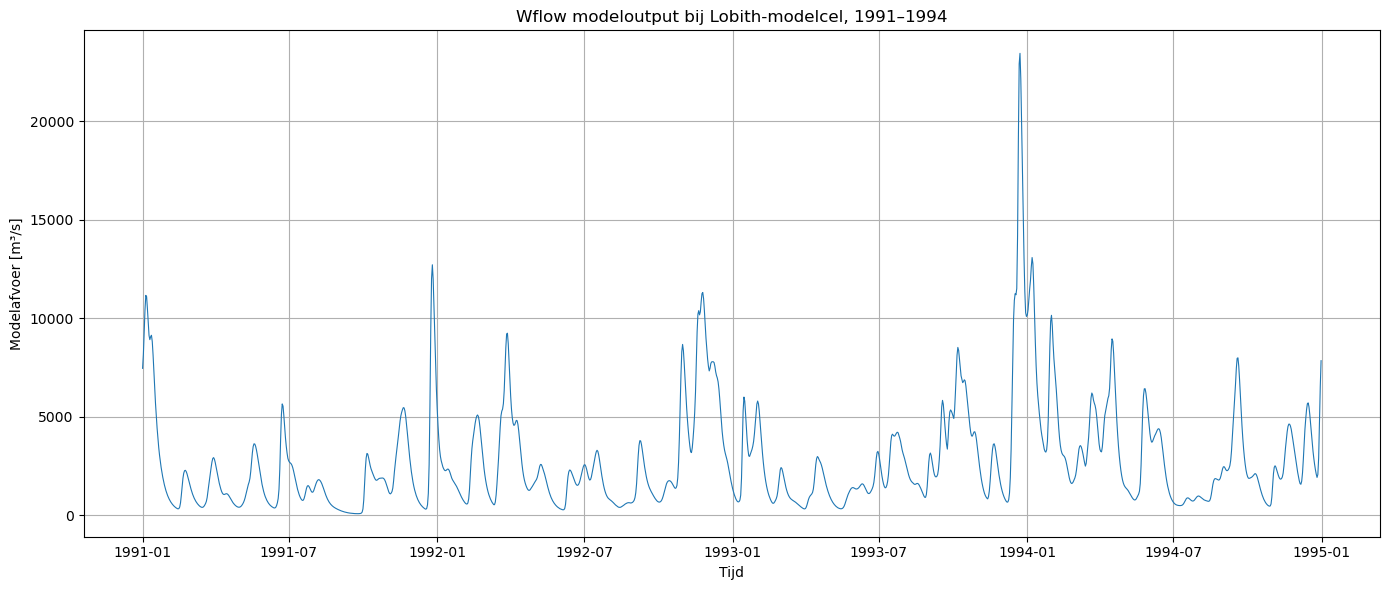

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    model_output_validation["date"],
    model_output_validation["Q_model_m3s"],
    linewidth=0.8
)

plt.xlabel("Tijd")
plt.ylabel("Modelafvoer [m³/s]")
plt.title("Wflow modeloutput bij Lobith-modelcel, 1991–1994")
plt.grid(True)

plt.tight_layout()
plt.show()